<a href="https://colab.research.google.com/github/nooshinmk-web/advanced-data-engineering-snowflake/blob/main/%20production-quality-visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_24308/2042078432.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="vehicle_id", y="fuel_consumption",
/tmp/ipykernel_24308/2042078432.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="vehicle_id", y="fuel_consumption",


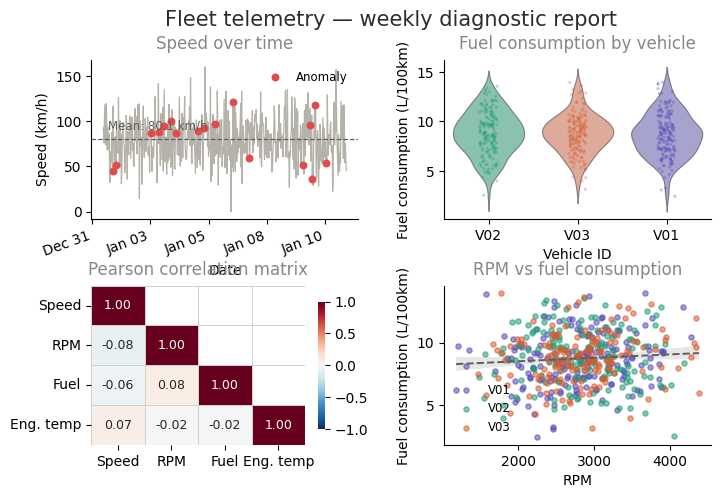

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


warnings.filterwarnings("ignore", message="Blended transforms not yet supported")

np.random.seed(42)
n = 500

df = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=n, freq="30min"),
    "speed_kmh": np.clip(np.random.normal(80, 25, n), 0, 160),
    "rpm": np.clip(np.random.normal(2800, 600, n), 500, 6000),
    "fuel_consumption": np.clip(np.random.normal(8.5, 2.1, n), 2, 18),
    "engine_temp_c": np.clip(np.random.normal(90, 10, n), 60, 120),
    "vehicle_id": np.random.choice(["V01", "V02", "V03"], n),
})
SUBTITLE_COLOR = "#888780"
ANNO_COLOR = "#5F5E5A"
df["anomaly"] = (df["rpm"] > 4500) | (df["engine_temp_c"] > 108)
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
fig.suptitle("Fleet telemetry — weekly diagnostic report", fontsize=15, fontweight="medium", y=0.98, color="#2C2C2A")
fig.patch.set_facecolor("white")
plt.subplots_adjust(hspace=0.42, wspace=0.32)

ax1= axes[0,0]
ax1.plot(df["timestamp"], df["speed_kmh"], color="#B4B2A9", linewidth=0.9, zorder=1)
anomalies = df[df["anomaly"]]
ax1.scatter(anomalies["timestamp"], anomalies["speed_kmh"],
            color="#E24B4A", s=22, zorder=3, label="Anomaly")

mean_speed = df["speed_kmh"].mean()
ax1.axhline(mean_speed, color=ANNO_COLOR, linestyle="--", linewidth=0.9, zorder=2)
ax1.annotate(f"Mean: {mean_speed:.1f} km/h",
             xy=(df["timestamp"].iloc[10], mean_speed),
             xytext=(0, 7), textcoords="offset points",
             fontsize=8.5, color=ANNO_COLOR)

ax1.set_title("Speed over time", color=SUBTITLE_COLOR, pad=8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Speed (km/h)")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")
ax1.legend(fontsize=8.5, frameon=False)
ax1.spines[["top", "right"]].set_visible(False)

PALETTE = {"V01": "#534AB7", "V02": "#1D9E75", "V03": "#D85A30"}

ax2 = axes[0, 1]
sns.violinplot(data=df, x="vehicle_id", y="fuel_consumption",
               palette=PALETTE, ax=ax2, inner=None, linewidth=0.8, alpha=0.55)
sns.stripplot(data=df, x="vehicle_id", y="fuel_consumption",
              palette=PALETTE, ax=ax2, size=2.2, alpha=0.35, jitter=True)
ax2.set_title("Fuel consumption by vehicle", color=SUBTITLE_COLOR, pad=8)
ax2.set_xlabel("Vehicle ID")
ax2.set_ylabel("Fuel consumption (L/100km)")
ax2.spines[["top", "right"]].set_visible(False)


ax3 = axes[1, 0]
#numeric_cols = ["speed_kmh", "rpm", "fuel_consumption", "engine_temp_c"]
corr = df[["speed_kmh", "rpm", "fuel_consumption", "engine_temp_c"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
labels = ["Speed", "RPM", "Fuel", "Eng. temp"]
sns.heatmap(corr, mask=mask, ax=ax3, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="#D3D1C7",
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
ax3.set_title("Pearson correlation matrix", color=SUBTITLE_COLOR, pad=8)


ax4 = axes[1, 1]
sns.regplot(data=df, x="rpm", y="fuel_consumption", ax=ax4, scatter=False, color=ANNO_COLOR, line_kws={"linewidth": 1.4, "linestyle": "--"})
for vid, grp in df.groupby("vehicle_id"):
  ax4.scatter(grp["rpm"], grp["fuel_consumption"], color=PALETTE[vid], s=14, alpha=0.55, label=vid)
  ax4.set_title("RPM vs fuel consumption", color=SUBTITLE_COLOR, pad=8)
  ax4.set_xlabel("RPM")
  ax4.set_ylabel("Fuel consumption (L/100km)")
  ax4.spines[["top", "right"]].set_visible(False)
  ax4.legend(fontsize=8.5, frameon=False)


